In [21]:
# Apply batch normalization and layer normalization to the deep RNN created in step 1.

from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib as mpl

def plot_learning_curves(loss, val_loss, title=None):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    if title:
        plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)


def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0094 - val_loss: 0.0042
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0031 - val_loss: 0.0034
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0029 - val_loss: 0.0033
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0029 - val_loss: 0.0033
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 

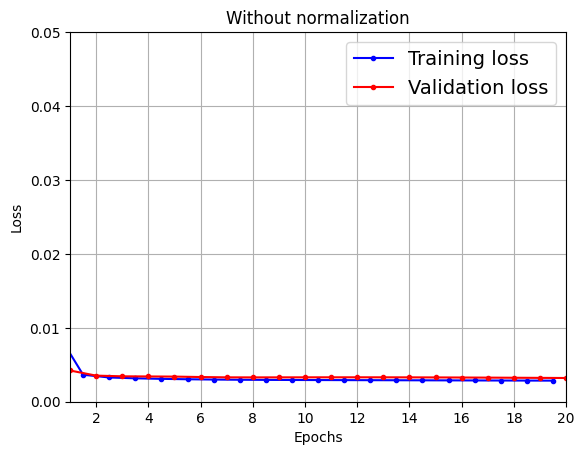

In [22]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))

print(model.evaluate(X_valid, y_valid))

baseline_mse = model.evaluate(X_valid, y_valid)

plot_learning_curves(history.history["loss"], history.history["val_loss"], title="Without normalization")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


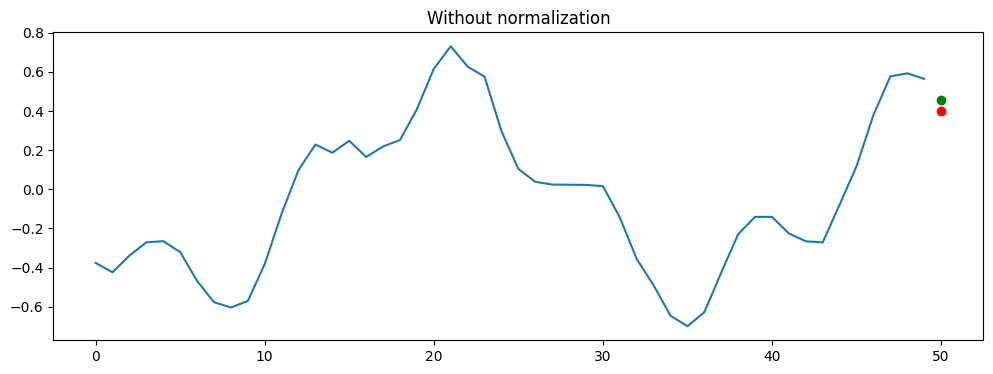

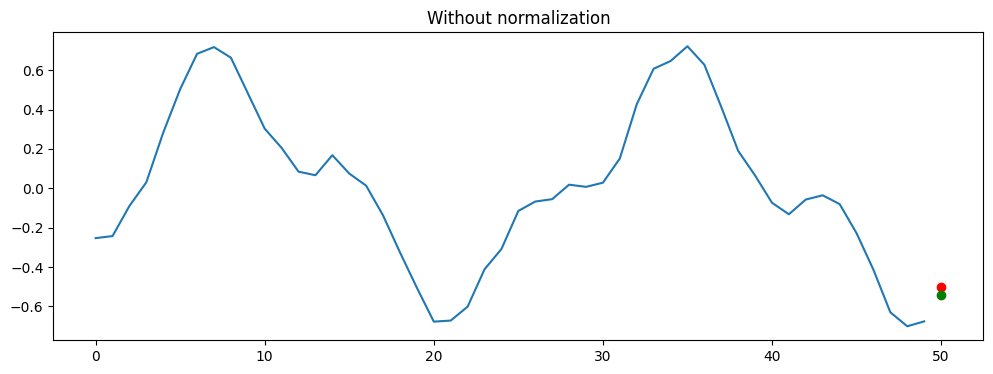

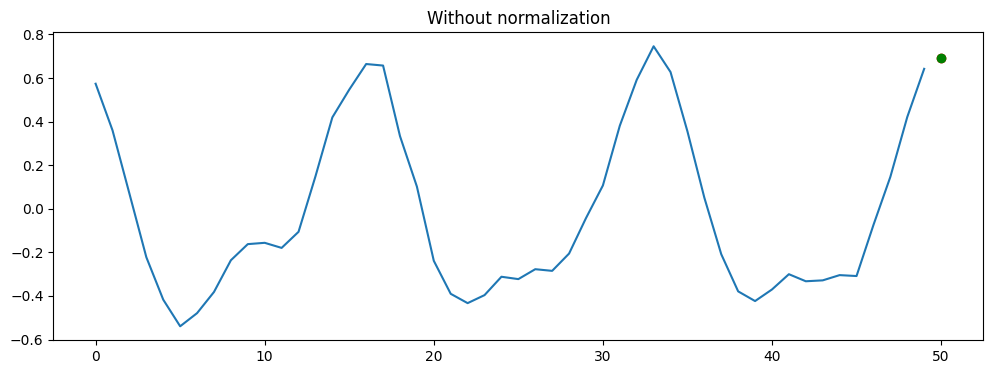

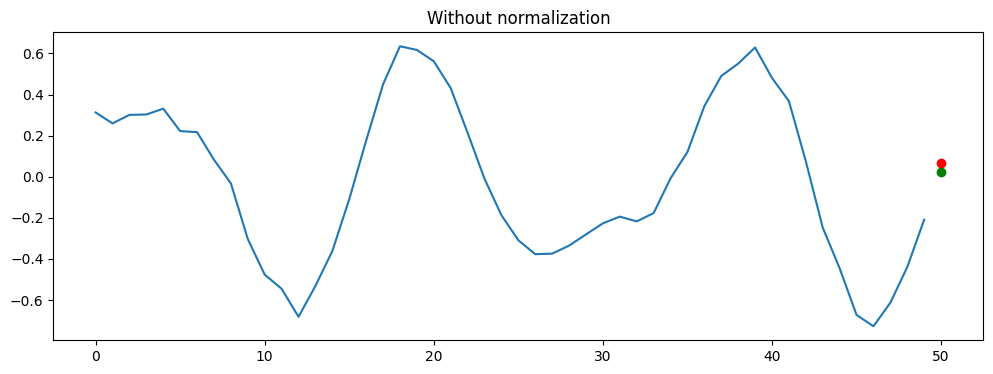

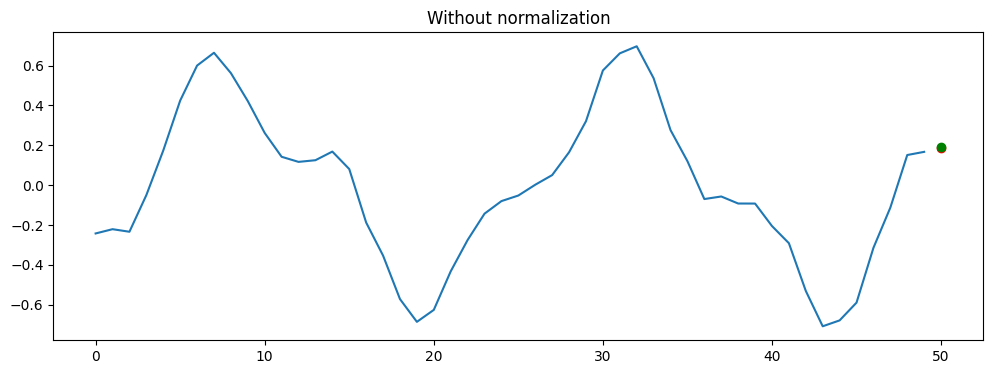

In [23]:
y_pred = model.predict(X_valid)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(X_valid[i])
    plt.title("Without normalization")
    plt.plot(50, y_valid[i], "ro")
    plt.plot(50, y_pred[i], "go")
plt.show()

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0203 - val_loss: 0.0051
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0039 - val_loss: 0.0038
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━

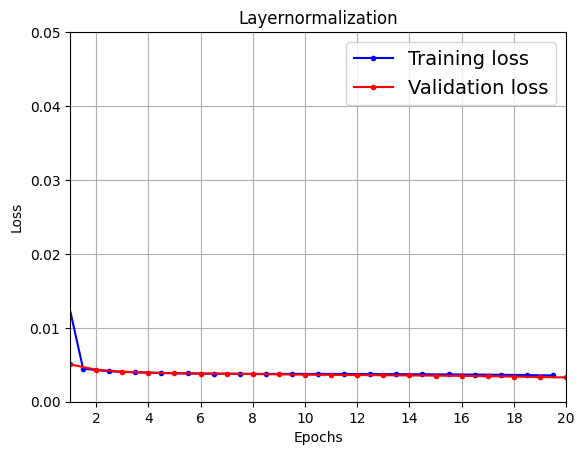

In [24]:
# with layer normalization

np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LayerNormalization(),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.LayerNormalization(),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))

print(model.evaluate(X_valid, y_valid))
layernorm_mse = model.evaluate(X_valid, y_valid)


plot_learning_curves(history.history["loss"], history.history["val_loss"], title="Layernormalization")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


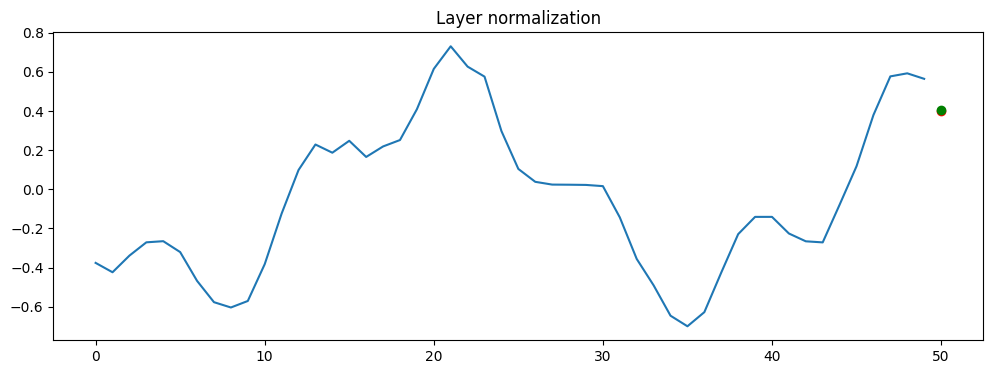

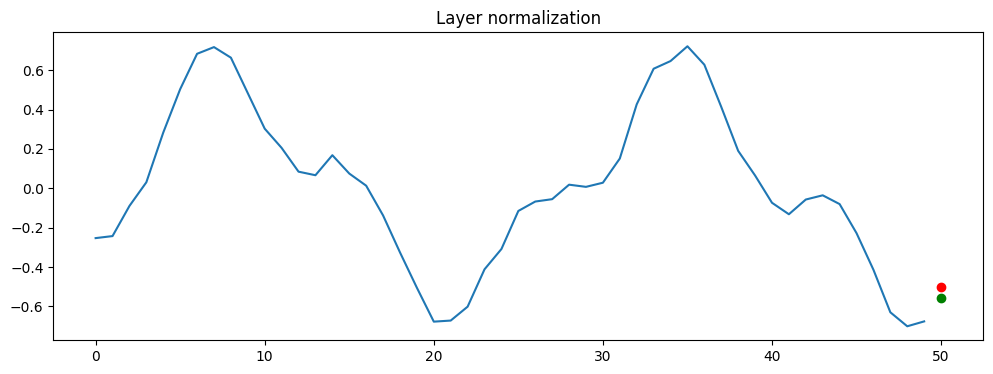

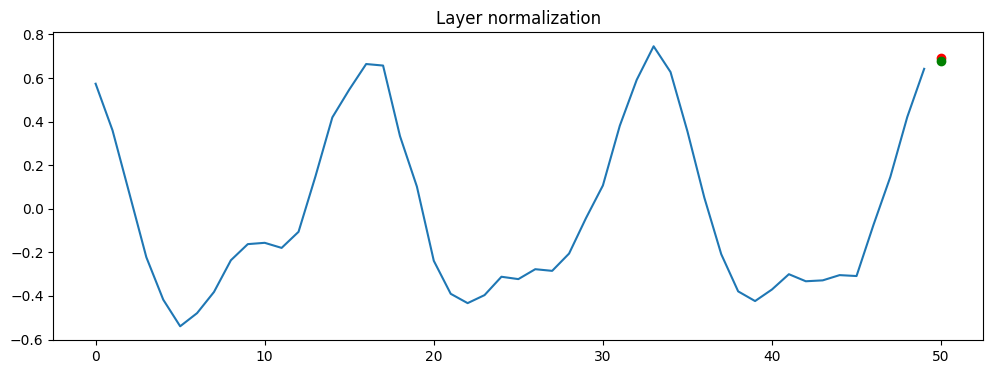

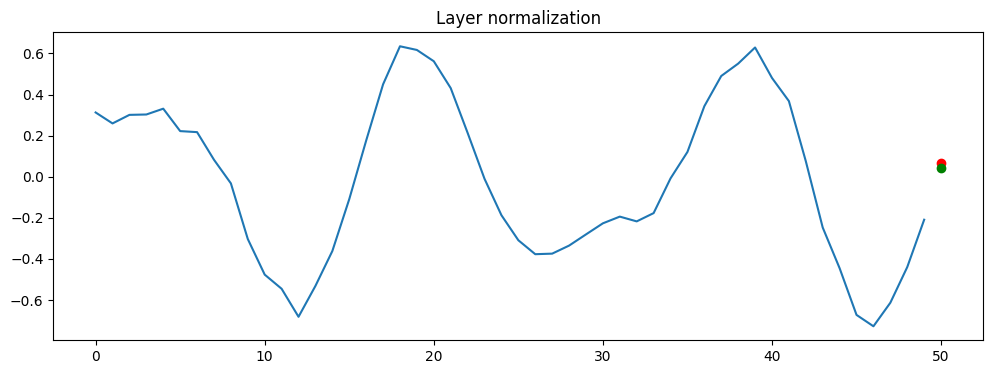

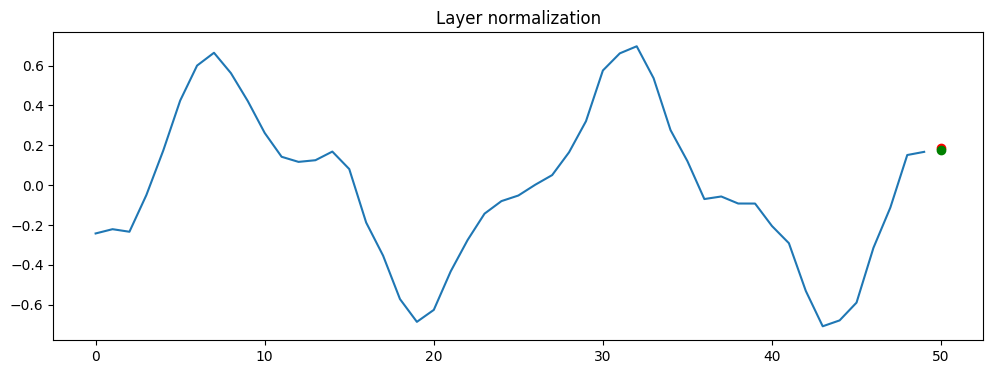

In [25]:
y_pred = model.predict(X_valid)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(X_valid[i])
    plt.title("Layer normalization")
    plt.plot(50, y_valid[i], "ro")
    plt.plot(50, y_pred[i], "go")
plt.show()

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - loss: 0.0475 - val_loss: 0.1766
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0101 - val_loss: 0.0145
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0077 - val_loss: 0.0056
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0066 - val_loss: 0.0057
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0054 - val_loss: 0.0052
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0045 - val_loss: 0.0048
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0045 - val_loss: 0.0047
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━

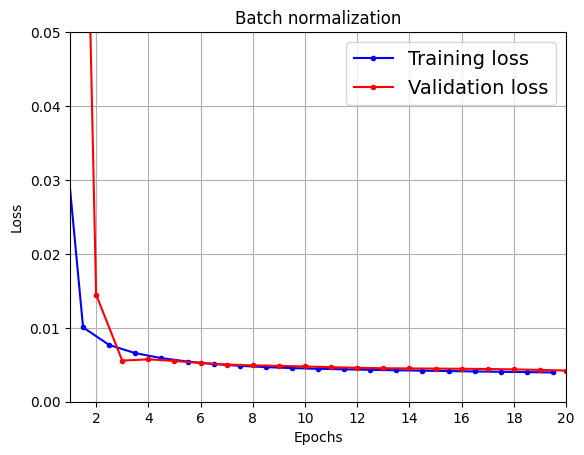

In [26]:
# with batch normalization

np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.BatchNormalization(),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.BatchNormalization(),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))

batchnorm_mse = model.evaluate(X_valid, y_valid)
print(model.evaluate(X_valid, y_valid))



plot_learning_curves(history.history["loss"], history.history["val_loss"], title="Batch normalization")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


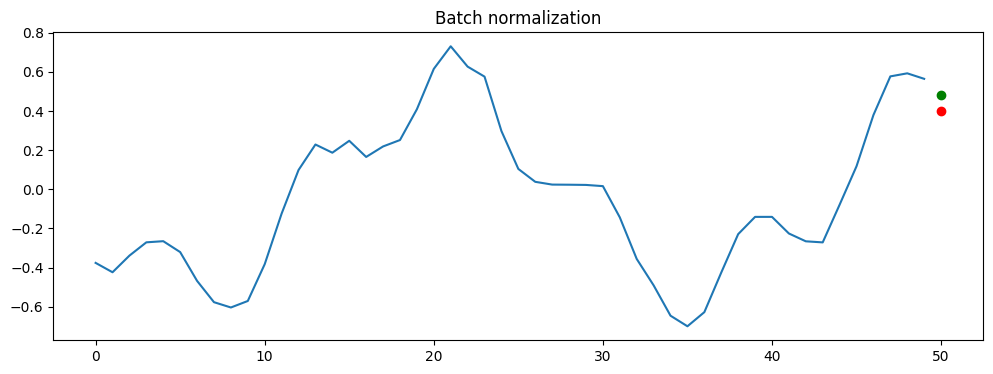

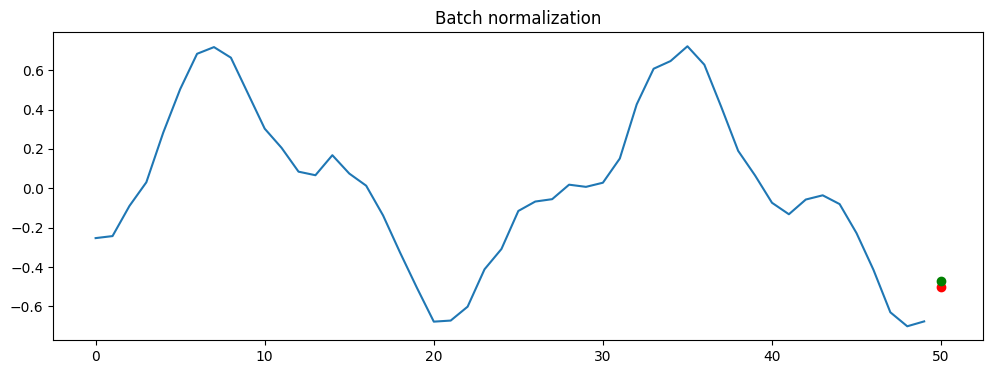

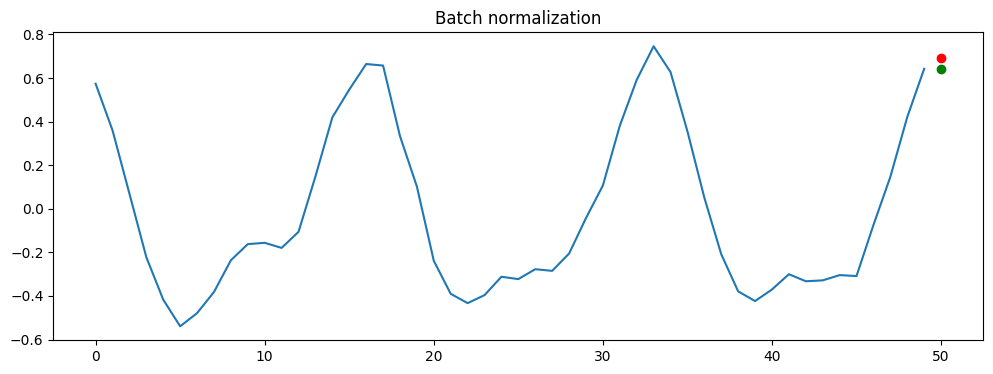

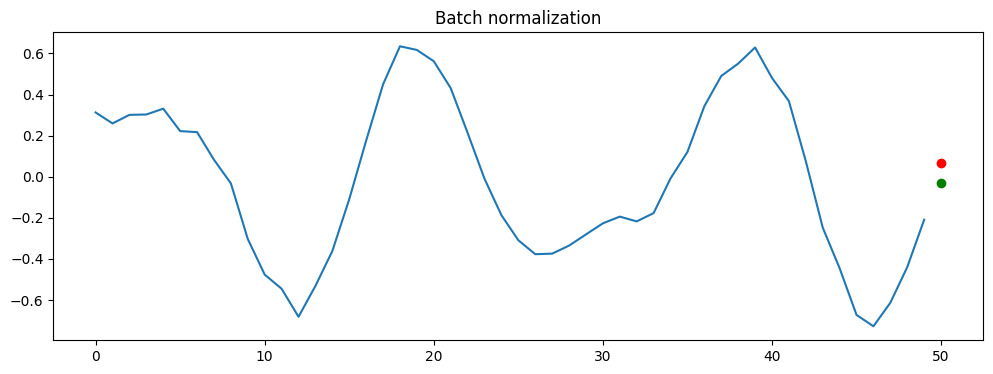

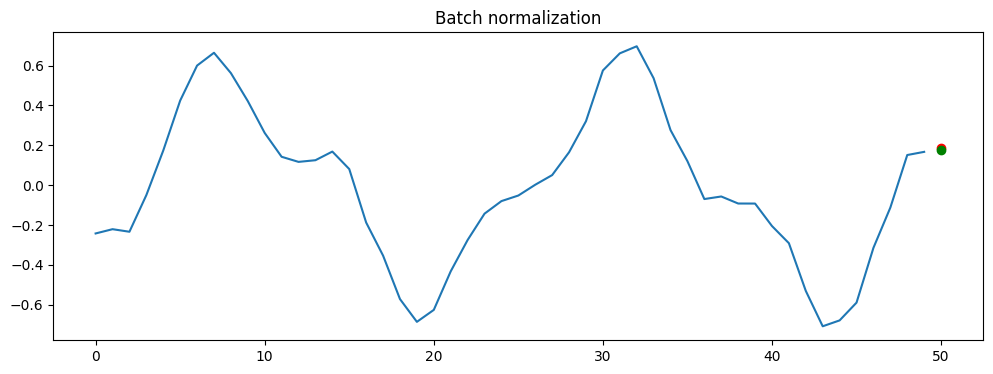

In [27]:
y_pred = model.predict(X_valid)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(X_valid[i])
    plt.title("Batch normalization")
    plt.plot(50, y_valid[i], "ro")
    plt.plot(50, y_pred[i], "go")
plt.show()

In [28]:
print(f"Baseline MSE: {baseline_mse}")
print(f"Batch normalization MSE: {batchnorm_mse}")
print(f"Layer normalization MSE: {layernorm_mse}")

Baseline MSE: 0.003067892976105213
Batch normalization MSE: 0.004257421009242535
Layer normalization MSE: 0.0030999190639704466
